In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils import resample
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, classification_report

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Dense, Dropout, BatchNormalization, Add, Concatenate)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

warnings.filterwarnings("ignore", category = FutureWarning)

In [2]:
'''

# === CARICAMENTO FILE ===
file_list = [
    "PSD_dataset_Bergantin_Fulvio_42.csv",
    "PSD_dataset_Cambareri_Chiara_26.csv",
    "PSD_dataset_Capria_Francesco_26.csv",
    "PSD_dataset_Capria_Alessandro_19.csv",
    "PSD_dataset_Cicirelli_Franco_50.csv",
    "PSD_dataset_Coppolillo_Erica_25.csv",
    "PSD_dataset_Damore_Francesco_45.csv",
    "PSD_dataset_DeMaio_Annarita_34.csv",
    "PSD_dataset_Falcone_Alberto_40.csv",
    "PSD_dataset_Folino_Gianluigi_52.csv",
    "PSD_dataset_Guarascio_Massimo_42.csv",
    "PSD_dataset_Guerrieri_Antonio_42.csv",
    "PSD_dataset_Islam_Md_Babul.csv",
    "PSD_dataset_Khan_Irfanullah_33.csv",
    "PSD_dataset_Macrì_Davide_44.csv",
    "PSD_dataset_Mariani_Luca_33.csv",
    "PSD_dataset_Mastroianni_Carlo_53.csv",
    "PSD_dataset_Miceli_Massimo_50.csv",
    "PSD_dataset_Minici_Marco_29.csv",
    "PSD_dataset_Mungari_Simone_26.csv",
    "PSD_dataset_Pena_Hindred_27.csv",
    "PSD_dataset_Pisani_Sergio_Francesco_40.csv",
    "PSD_dataset_Qimeng_Li_37.csv",
    "PSD_dataset_Rizzo_Luigi_39.csv",
    "PSD_dataset_Scala_Francesco_33.csv",
    "PSD_dataset_Vinci_Andrea_40.csv",
    "PSD_dataset_Zicari_Paolo_51.csv"
]

train_list, test_list = [], []

for file in file_list:
    df = pd.read_csv(file)
    
    # Separazione feature e target
    X = df.drop("Event Id", axis=1).astype(float)
    y = df["Event Id"]

    # Split stratificato (10% train, 90% test)
    X_train_part, X_test_part, y_train_part, y_test_part = train_test_split(
        X, y, test_size=0.5, shuffle=True, stratify=y, random_state=42
    )

    # Ricostruzione DataFrame
    train_df = pd.DataFrame(X_train_part)
    train_df["Event Id"] = y_train_part.values
    test_df = pd.DataFrame(X_test_part)
    test_df["Event Id"] = y_test_part.values

    train_list.append(train_df)
    test_list.append(test_df)

# Concatenazione dei dataset finali
train_final = pd.concat(train_list, ignore_index=True)
test_final = pd.concat(test_list, ignore_index=True)

# Separazione X e y
X_train = train_final.drop("Event Id", axis=1).astype(float)
y_train = train_final["Event Id"]
X_test = test_final.drop("Event Id", axis=1).astype(float)
y_test = test_final["Event Id"]

# Normalizzazione
scaler = MinMaxScaler()
X_scaled_train = scaler.fit_transform(X_train)
X_scaled_test = scaler.transform(X_test)

# === OVERSAMPLING DEL TRAINING SET ===
train_df = pd.DataFrame(X_scaled_train)
train_df["Event Id"] = y_train.values

# Conteggio classi
class_counts = train_df["Event Id"].value_counts()
max_samples = class_counts.max()

# Oversampling di tutte le classi minoritarie
balanced_dfs = []
for cls, count in class_counts.items():
    df_cls = train_df[train_df["Event Id"] == cls]
    if count < max_samples:
        df_upsampled = resample(df_cls, replace=True, n_samples=max_samples, random_state=42)
    else:
        df_upsampled = df_cls
    balanced_dfs.append(df_upsampled)

# Unione e shuffle
df_train_balanced_OS = pd.concat(balanced_dfs)
df_train_balanced_OS = df_train_balanced_OS.sample(frac=1, random_state=42)

# Finali X e y bilanciati
X_train_balanced_OS = df_train_balanced_OS.drop("Event Id", axis=1).values
y_train_balanced_OS = df_train_balanced_OS["Event Id"].values
'''


'\n\n# === CARICAMENTO FILE ===\nfile_list = [\n    "PSD_dataset_Bergantin_Fulvio_42.csv",\n    "PSD_dataset_Cambareri_Chiara_26.csv",\n    "PSD_dataset_Capria_Francesco_26.csv",\n    "PSD_dataset_Capria_Alessandro_19.csv",\n    "PSD_dataset_Cicirelli_Franco_50.csv",\n    "PSD_dataset_Coppolillo_Erica_25.csv",\n    "PSD_dataset_Damore_Francesco_45.csv",\n    "PSD_dataset_DeMaio_Annarita_34.csv",\n    "PSD_dataset_Falcone_Alberto_40.csv",\n    "PSD_dataset_Folino_Gianluigi_52.csv",\n    "PSD_dataset_Guarascio_Massimo_42.csv",\n    "PSD_dataset_Guerrieri_Antonio_42.csv",\n    "PSD_dataset_Islam_Md_Babul.csv",\n    "PSD_dataset_Khan_Irfanullah_33.csv",\n    "PSD_dataset_Macrì_Davide_44.csv",\n    "PSD_dataset_Mariani_Luca_33.csv",\n    "PSD_dataset_Mastroianni_Carlo_53.csv",\n    "PSD_dataset_Miceli_Massimo_50.csv",\n    "PSD_dataset_Minici_Marco_29.csv",\n    "PSD_dataset_Mungari_Simone_26.csv",\n    "PSD_dataset_Pena_Hindred_27.csv",\n    "PSD_dataset_Pisani_Sergio_Francesco_40.csv",\n 

In [3]:
from sklearn.model_selection import StratifiedKFold

# === CARICAMENTO FILE ===
file_list = [
    "PSD_dataset_Bergantin_Fulvio_42.csv",
    "PSD_dataset_Cambareri_Chiara_26.csv",
    "PSD_dataset_Capria_Francesco_26.csv",
    "PSD_dataset_Capria_Alessandro_19.csv",
    "PSD_dataset_Cicirelli_Franco_50.csv",
    "PSD_dataset_Coppolillo_Erica_25.csv",
    "PSD_dataset_Damore_Francesco_45.csv",
    "PSD_dataset_DeMaio_Annarita_34.csv",
    "PSD_dataset_Falcone_Alberto_40.csv",
    "PSD_dataset_Folino_Gianluigi_52.csv",
    "PSD_dataset_Guarascio_Massimo_42.csv",
    "PSD_dataset_Guerrieri_Antonio_42.csv",
    "PSD_dataset_Islam_Md_Babul.csv",
    "PSD_dataset_Khan_Irfanullah_33.csv",
    "PSD_dataset_Macrì_Davide_44.csv",
    "PSD_dataset_Mariani_Luca_33.csv",
    "PSD_dataset_Mastroianni_Carlo_53.csv",
    "PSD_dataset_Miceli_Massimo_50.csv",
    "PSD_dataset_Minici_Marco_29.csv",
    "PSD_dataset_Mungari_Simone_26.csv",
    "PSD_dataset_Pena_Hindred_27.csv",
    "PSD_dataset_Pisani_Sergio_Francesco_40.csv",
    "PSD_dataset_Qimeng_Li_37.csv",
    "PSD_dataset_Rizzo_Luigi_39.csv",
    "PSD_dataset_Scala_Francesco_33.csv",
    "PSD_dataset_Vinci_Andrea_40.csv",
    "PSD_dataset_Zicari_Paolo_51.csv"
]

train_list, test_list = [], []

for file in file_list:
    df = pd.read_csv(file)
    
    # Separazione feature e target
    X = df.drop("Event Id", axis=1).astype(float)
    y = df["Event Id"]

    # Split stratificato (50% train, 50% test)
    X_train_part, X_test_part, y_train_part, y_test_part = train_test_split(
        X, y, test_size=0.5, shuffle=True, stratify=y, random_state=42
    )

    # Ricostruzione DataFrame
    train_df = pd.DataFrame(X_train_part)
    train_df["Event Id"] = y_train_part.values
    test_df = pd.DataFrame(X_test_part)
    test_df["Event Id"] = y_test_part.values

    train_list.append(train_df)
    test_list.append(test_df)

# === CONCATENAZIONE TRAIN E TEST GLOBALI ===
train_final = pd.concat(train_list, ignore_index=True)
test_final = pd.concat(test_list, ignore_index=True)

# === SUDDIVISIONE TRAINING IN 10 PARTI STRATIFICATE ===
X_train = train_final.drop("Event Id", axis=1).astype(float).values
y_train = train_final["Event Id"].values

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

partition_list = []
for i, (train_idx, _) in enumerate(skf.split(X_train, y_train)):
    X_part = X_train[train_idx]
    y_part = y_train[train_idx]
    df_part = pd.DataFrame(X_part)
    df_part["Event Id"] = y_part
    partition_list.append(df_part)

# Parti Training Set:
p1 = partition_list[0]
p2 = partition_list[1]
p3 = partition_list[2]
p4 = partition_list[3]
p5 = partition_list[4]
p6 = partition_list[5]
p7 = partition_list[6]
p8 = partition_list[7]
p9 = partition_list[8]
p10 = partition_list[9]


# === NORMALIZZAZIONE TEST ===
X_test = test_final.drop("Event Id", axis=1).astype(float)
y_test = test_final["Event Id"]

scaler = MinMaxScaler()
scaler.fit(X_train)  # Fit solo sui dati di training (globali)
X_scaled_test = scaler.transform(X_test)

# Numero di Parti da prendere per il training (da p1 a p10)
train_subset = pd.concat([p1, p2, p3, p4, p5, p6, p7, p8, p9, p10], ignore_index=True)

X_train_subset = train_subset.drop("Event Id", axis=1).values
y_train_subset = train_subset["Event Id"].values

X_train_scaled = scaler.transform(X_train_subset)

# Oversampling
df_train_subset = pd.DataFrame(X_train_scaled)
df_train_subset["Event Id"] = y_train_subset

class_counts = df_train_subset["Event Id"].value_counts()
max_samples = class_counts.max()

balanced_dfs = []
for cls, count in class_counts.items():
    df_cls = df_train_subset[df_train_subset["Event Id"] == cls]
    if count < max_samples:
        df_upsampled = resample(df_cls, replace=True, n_samples=max_samples, random_state=42)
    else:
        df_upsampled = df_cls
    balanced_dfs.append(df_upsampled)

df_train_balanced_OS = pd.concat(balanced_dfs).sample(frac=1, random_state=42)
X_train_balanced_OS = df_train_balanced_OS.drop("Event Id", axis=1).values
y_train_balanced_OS = df_train_balanced_OS["Event Id"].values


C:\Users\franc\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


<Figure size 1000x500 with 0 Axes>

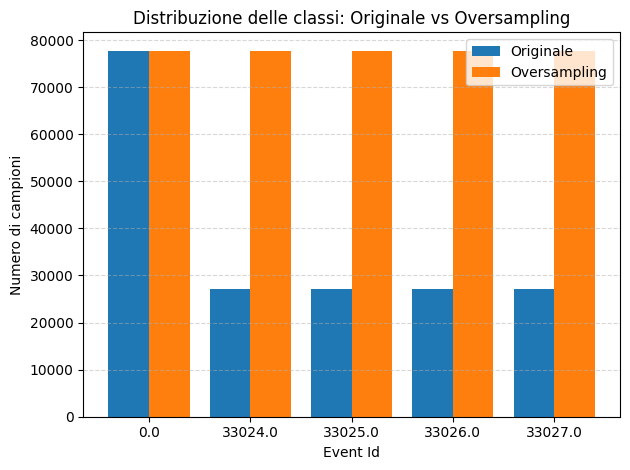

In [4]:
### --- PLOT DISTRIBUZIONE ORIGINALE VS OVERSAMPLING --- ###

# === DISTRIBUZIONE ORIGINALE ===
original_counts = df_train_subset["Event Id"].value_counts().sort_index()
oversampled_counts = df_train_balanced_OS["Event Id"].value_counts().sort_index()

# Unione in un unico DataFrame
comparison_df = pd.DataFrame({
    "Originale": original_counts,
    "Oversampling": oversampled_counts
})

# === GRAFICO ===
plt.figure(figsize=(10, 5))
comparison_df.plot(kind="bar", width=0.8)
plt.title("Distribuzione delle classi: Originale vs Oversampling")
plt.xlabel("Event Id")
plt.ylabel("Numero di campioni")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


Classe 0: peso 1.00
Classe 33024: peso 1.00
Classe 33025: peso 1.00
Classe 33026: peso 1.00
Classe 33027: peso 1.00
649/649 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Model Accuracy (Neural Network): 0.79
col_0    0.0      33024.0  33025.0  33026.0  33027.0
Actual                                              
0.0         6825      535      377      373      531
33024.0      407     2417       79       55       66
33025.0      433       83     2355       62       91
33026.0      430       51       72     2397       74
33027.0      411       88       89       66     2370
              precision    recall  f1-score   support

         0.0       0.80      0.79      0.80      8641
     33024.0       0.76      0.80      0.78      3024
     33025.0       0.79      0.78      0.79      3024
     33026.0       0.81      0.79      0.80      3024
     33027.0       0.76      0.78      0.77      3024

    accuracy                           0.79     20737
   macro avg       0.78      0.79      0.79     20737


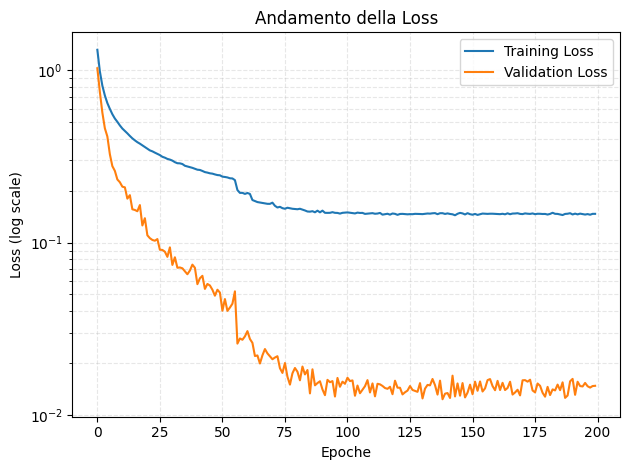

In [5]:
# === CALLBACKS ===
checkpoint = ModelCheckpoint(
    filepath="best_m.weights.h5",            # File dove salvare i pesi migliori
    monitor='val_loss',              # Valutazione in base alla accuratezza di validazione
    save_best_only=True,
    save_weights_only=True,
    mode='min',
    verbose=0
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',                  # Se la val_loss non migliora...
    factor=0.5,                          # ...dimezza il learning rate
    patience=5,                          # dopo 5 epoche senza miglioramento
    min_lr=1e-6,                         # learning rate minimo
    verbose=0
)

callbacks_list = [checkpoint, reduce_lr]


# === PREPARAZIONE ONE-HOT ENCODING ===
#
classes = np.sort(np.unique(np.concatenate([y_train_balanced_OS, y_test])))
to_index = {c: i for i, c in enumerate(classes)}

y_train_cat = to_categorical([to_index[c] for c in y_train_balanced_OS],
                             num_classes=len(classes))
y_test_cat = to_categorical([to_index[c] for c in y_test],
                            num_classes=len(classes))


### --- CALCOLO DEI PESI --- ###

# Calcola i pesi automaticamente in base alla distribuzione delle classi
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_balanced_OS),
    y=y_train_balanced_OS
)


# Converte in dizionario per TensorFlow
class_weights = dict(zip(np.unique(y_train), class_weights_array))

# Visualizza i pesi per capire cosa sta succedendo
for cls, weight in class_weights.items():
    print(f"Classe {int(cls)}: peso {weight:.2f}")
    


# === COSTRUZIONE MODELLO MLP ===

def create_residual(input_layer, factors, dropout_pcg):

    #l2
    out = Dense(factors, activation="relu") (input_layer)
    out = BatchNormalization() (out)
    out = Dropout(dropout_pcg) (out)

    #add 
    out = Add()([out,input_layer])

    #l3
    out = Dense(factors, activation="relu") (out)
    out = BatchNormalization() (out)
    out = Dropout(dropout_pcg) (out)
    
    return out


def create_dnn_tf_func(dimensions, factors = 256): #hidden layers tutti con le stesse dimensioni

    dropout_pcg = 0.25   # spegne un numero di nodi casuali per ridurre l'overfitting (Es. 0.25 riduce il 25%)
    
    input_layer = tf.keras.layers.Input(shape=(dimensions,))
    

    #l1
    out = Dense(factors, activation="relu") (input_layer)
    out = BatchNormalization() (out)
    out = Dropout(dropout_pcg) (out)
    
    #create residual 
    out_1 = create_residual(out, factors, dropout_pcg)
    #out_2 = create_residual(out, factors, dropout_pcg)    #per aggiungere un ulteriore residual block
    
    out = Concatenate()([out_1, input_layer])
    #out = Concatenate()([out_1, out_2, input_layer])
    #out = Concatenate()([out_1, out_2])
   
    #lp
    out = Dense(len(classes), activation='softmax') (out)
    
    
    model = tf.keras.models.Model(inputs=[input_layer], outputs=out)

    #opt = optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, epsilon=1e-14)
    #opt = optimizers.Adam(learning_rate=1e-4, beta_1=0.9, beta_2=0.999, epsilon=1e-7)
    opt =tf.keras.optimizers.RMSprop(learning_rate=0.001, epsilon=1e-14)

    model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy']) 

    return (model, input_layer, out)


model_init = create_dnn_tf_func(X_train_balanced_OS.shape[1])
    
model = model_init[0]
model_input = model_init[1]
model_output = model_init[2]


# === ADDDESTRAMENTO ===
#history = model.fit(X_train_balanced_OS, y_train_cat, validation_split=0.2, epochs=250, batch_size=64, callbacks=[callbacks_list], class_weight=class_weights, verbose=0)
history = model.fit(X_train_balanced_OS, y_train_cat, validation_split=0.2, epochs=200, batch_size=128, callbacks=[callbacks_list], verbose=0)


# === CARICAMENTO PESI MIGLIORI SALVATI ===
model.load_weights("best_m.weights.h5")

# === PREDIZIONE ===
y_hat_nn = model.predict(X_scaled_test)
y_hat_nn_labels = classes[np.argmax(y_hat_nn, axis=1)]
y_actu_nn = pd.Series(y_test, name='Actual')
df_confusion_nn = pd.crosstab(y_actu_nn, y_hat_nn_labels)

# === VALUTAZIONE ===
acc_nn = accuracy_score(y_test, y_hat_nn_labels)
print("Model Accuracy (Neural Network): %.2f" % acc_nn)
print(df_confusion_nn)
print(classification_report(y_test, y_hat_nn_labels))



plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Andamento della Loss')
plt.yscale('log')
plt.xlabel('Epoche')
plt.ylabel('Loss (log scale)')
plt.legend()
plt.grid(True, which='both', ls='--', alpha=0.3)
plt.tight_layout()
plt.show()